In [1]:
from FPSim2.scripts.create_fpsim2_fp_db import create_db_file_parallel
import dask.dataframe as dd
import os
from FPSim2 import FPSim2Engine
import pandas as pd
import pickle as pk
import datamol as dm

In [3]:
data = dd.read_parquet("test1/*.parquet")
len(data)

4175752

In [4]:
create_db_file_parallel(
    smi_file="test.smi", 
    out_file="pattern_screenout.h5", 
    fp_type="RDKitPattern", 
    fp_params={}, 
    full_sanitization=False, 
    num_processes=4
)

In [9]:
os.path.getsize('pattern_screenout.h5') /1024**3 * 134_100_000_000/4175752

22128.288529745536

### Search analogues

In [5]:
fp_filename = 'original.h5'
fpe = FPSim2Engine(fp_filename)
search = {}
tanimoto = {}
query = 'CN(Cc1ccco1)C(=O)c2ccon2'
results = fpe.top_k(query, k=100, threshold=0.6, metric='tanimoto', n_workers=4)

search[query] = [(int(x["mol_id"]), float(x["coeff"])) for x in results]
tanimoto[query] = pd.Series({int(x[0]): float(x[1]) for x in results}).rename("Tanimoto")

search

{'CN(Cc1ccco1)C(=O)c2ccon2': [(1, 1.0),
  (796, 0.6904761791229248),
  (12, 0.6511628031730652),
  (2, 0.6499999761581421),
  (3854, 0.6363636255264282),
  (3821, 0.6279069781303406),
  (17841, 0.6222222447395325),
  (3732, 0.6136363744735718),
  (795, 0.6136363744735718),
  (2949, 0.6136363744735718),
  (2199, 0.6136363744735718),
  (7, 0.604651153087616),
  (794, 0.604651153087616),
  (2201, 0.6000000238418579),
  (3069, 0.6000000238418579)]}

In [ ]:
with open(f"search_res.pkl", "wb") as js:
    pk.dump(search, js)

In [12]:
with open("search_res.pkl", "rb") as js:
    res = pk.load(js) 
for query, item in res.items():
    print(item[:10])

[(1, 1.0), (796, 0.6904761791229248), (12, 0.6511628031730652), (2, 0.6499999761581421), (3854, 0.6363636255264282), (3821, 0.6279069781303406), (17841, 0.6222222447395325), (3732, 0.6136363744735718), (795, 0.6136363744735718), (2949, 0.6136363744735718)]


In [13]:
{query: sorted(item, key=lambda x: x[1], reverse=True)[:10] for query, item in res.items()}

{'CN(Cc1ccco1)C(=O)c2ccon2': [(1, 1.0),
  (796, 0.6904761791229248),
  (12, 0.6511628031730652),
  (2, 0.6499999761581421),
  (3854, 0.6363636255264282),
  (3821, 0.6279069781303406),
  (17841, 0.6222222447395325),
  (3732, 0.6136363744735718),
  (795, 0.6136363744735718),
  (2949, 0.6136363744735718)]}

### Search substructure

In [2]:
from rdkit import Chem, RDLogger
from rdkit.Chem.MolStandardize import rdMolStandardize
import pandas as pd
import datamol as dm
from dask.distributed import Client
from functools import partial

In [ ]:
client = Client(n_workers=4)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 31.08 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33195,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46723,Total threads: 2
Dashboard: http://127.0.0.1:42505/status,Memory: 7.77 GiB
Nanny: tcp://127.0.0.1:36237,


In [9]:
fp_filename = "pattern_screenout.h5"
fpe = FPSim2Engine(fp_filename, in_memory_fps=False)

query = 'c1ccc(S(=O)(=O)N)cc1'
results = fpe.on_disk_substructure(query, n_workers=4)

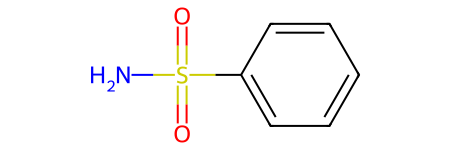

In [12]:
dm.to_mol(query)

In [10]:
search = {}
search["query"] = [int(x) for x in results]

In [11]:
sort = sorted([int(s) for s in results])
len(sort)

26301

In [13]:
import duckdb 
db = duckdb.connect()

In [14]:
res = db.execute(f"SELECT SMILES, num_ID FROM read_parquet($path) WHERE num_ID in $query", {"path":["test1/*.parquet"],  "query": sort}).df()

In [15]:
res[res["num_ID"].isin(sort)]

,SMILES,num_ID
0,Cc1ccc(cc1C)S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3,19
1,c1cc(ccc1NC(=O)c2ccon2)S(=O)(=O)N3CCNCC3,36
2,c1cc(ccc1N)S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3,37
3,CNS(=O)(=O)c1ccc(cc1)NC(=O)c2ccon2,41
4,Cc1ccc(c(c1)S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3)C,49
...,...,...
26296,C[C@@H]1CCCN(C1)S(=O)(=O)c2ccc(cc2)NC(=O)[C@@H...,4172083
26297,C[C@H]1CCCN(C1)S(=O)(=O)c2ccc(cc2)NC(=O)[C@@H]...,4172084
26298,Cc1ccc(cc1NC(=O)[C@H]2CC(=O)OC23CCCC3)S(=O)(=O)N,4174135
26299,c1ccc(cc1)S(=O)(=O)N2CCC(CC2)NC(=O)[C@H]3CC(=O...,4174373


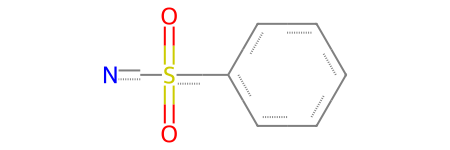

In [17]:
query_mol = Chem.MolFromSmarts(query)
def match_smiles(smi, query_mol=query_mol):
    mol = dm.to_mol(smi)
    if mol is None:
        return False
    return mol.HasSubstructMatch(query_mol)
query_mol

In [18]:
for smi in res["SMILES"].values:
    if match_smiles(smi):
        print(smi)

Cc1ccc(cc1C)S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3
c1cc(ccc1NC(=O)c2ccon2)S(=O)(=O)N3CCNCC3
c1cc(ccc1N)S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3
CNS(=O)(=O)c1ccc(cc1)NC(=O)c2ccon2
Cc1ccc(c(c1)S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3)C
c1cc(ccc1NC(=O)c2ccon2)S(=O)(=O)N3CCCC3
c1cc(ccc1S(=O)(=O)N2CCN(CC2)C(=O)c3ccon3)Cl
c1cc(ccc1NC(=O)c2ccon2)S(=O)(=O)N3CCCCCC3
C[C@H]1CCCN(C1)S(=O)(=O)c2ccc(cc2)NC(=O)c3ccon3
CNS(=O)(=O)c1ccccc1NC(=O)c2ccon2
c1cc(c(cc1S(=O)(=O)N)O)NC(=O)c2ccon2
CNS(=O)(=O)c1cccc(c1)NC(=O)c2ccon2
c1cc(c(cc1S(=O)(=O)N)NC(=O)c2ccon2)Cl
c1cnn(c1)CC(=O)Nc2ccc(cc2)S(=O)(=O)N3CCOCC3
Cc1ccc(cc1C)S(=O)(=O)N2CCN(CC2)C(=O)Cn3cccn3
c1cnn(c1)CC(=O)Nc2ccc(cc2)S(=O)(=O)N3CCNCC3
CN(C)S(=O)(=O)c1ccc(cc1)NC(=O)Cn2cccn2
c1cnn(c1)CC(=O)N2CCN(CC2)S(=O)(=O)c3ccc(cc3)F
c1ccc(cc1)S(=O)(=O)N2CCN(CC2)C(=O)Cn3cccn3
Cc1ccc(cc1)S(=O)(=O)N2CCN(CC2)C(=O)Cn3cccn3
CN1CCN(CC1)S(=O)(=O)c2ccc(cc2)NC(=O)Cn3cccn3
C[C@@H]1CCCN(C1)S(=O)(=O)c2ccc(cc2)NC(=O)Cn3cccn3
c1ccc(cc1)S(=O)(=O)N2CCC(CC2)NC(=O)Cn3cccn3
CNS(=O)(=O)c1ccccc1NC(=O)Cn2cc

In [19]:
a = res.drop_duplicates(subset=["num_ID"])
#mols = dm.from_df(a, smiles_column="SMILES")
mask = dm.parallelized(partial(match_smiles, query_mol=query_mol), a["SMILES"], n_jobs=4, progress=False, scheduler="threads")

/home/ruite/miniforge3/envs/ai_factory/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


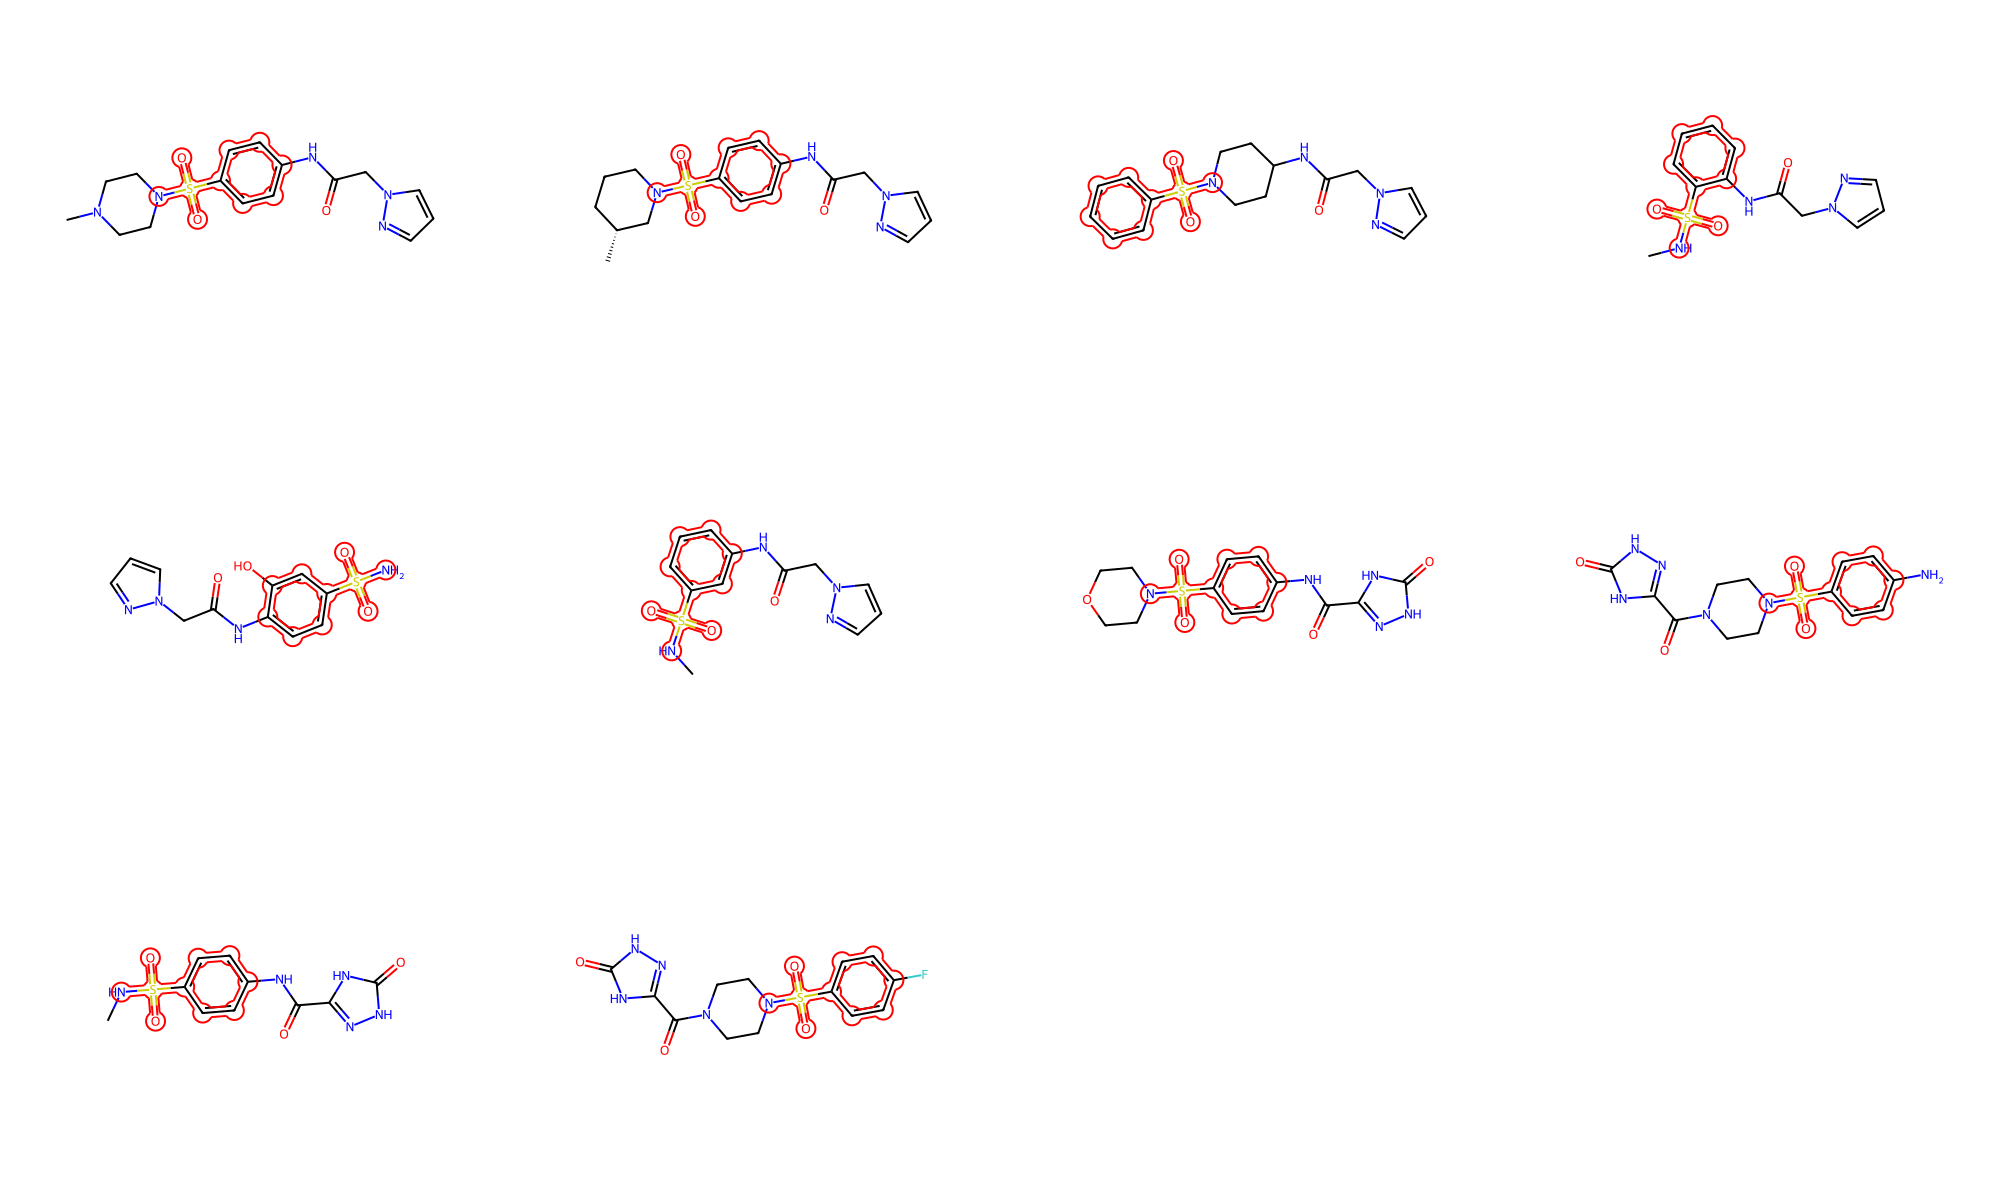

In [25]:
dm.lasso_highlight_image(list(a[mask]["SMILES"].values[20:30]), [query], mol_size=(500, 400), use_svg=False)

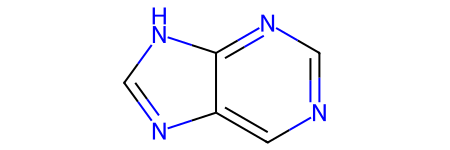

In [ ]:


p = Chem.MolFromSmiles('[nH]1cnc2cncnc21')
p

In [10]:
a = pd.Series({2:4,5:7})
a.rename("tanimoto")

2    4
5    7
Name: tanimoto, dtype: int64

### Generate conformers

In [2]:
import datamol as dm
from molfeat.trans.fp import FPVecTransformer
from rdkit import DataStructs

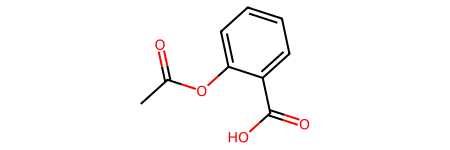

In [11]:
smi = "O=C(C)Oc1ccccc1C(=O)O"
mol = dm.to_mol(smi)
smi = dm.to_smiles(mol, canonical=True, isomeric=False)
mol = dm.to_mol(smi)
mol

In [22]:
a = dm.conformers.generate(mol, n_confs=10, align_conformers=True, minimize_energy=True)
conf = a.GetConformers()

In [ ]:
import numpy as np

def normalized_distances_to_reference(vectors, reference_idx=0):
    """
    1. Normalize features to comparable ranges
    2. Compute distances in normalized space
    """
    # Method A: Min-max normalization per feature
    min_vals = vectors.min(axis=0)
    max_vals = vectors.max(axis=0)
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1  # Avoid division by zero
    normalized = (vectors - min_vals) / range_vals
    
    # Reference in normalized space
    ref_norm = normalized[reference_idx]
    
    # Distances in normalized space
    distances = np.sqrt(np.sum((normalized - ref_norm) ** 2, axis=1))
    ranking = np.argsort(distances)
    
    return distances, ranking, normalized

# Usage


# Example usage
vectors = np.array([
    [0, 10, 100],   # Small, medium, large counts
    [5, 20, 50],
    [1, 5, 200],
    [0, 0, 300]
])

distances, ranking, normalized = normalized_distances_to_reference(vectors, 0)

[  5  20 250]
[  5  20 250]


In [61]:
vectors.min(axis=0)

array([ 0,  0, 50])

### Ekaitz

In [45]:
mols = pd.read_csv("/home/ruite/Projects/AI factory/TPP_prot_query_results.csv", index_col=[0,1])
mols

ID  \
                                                   SMILES                                                                             
Cc1ncc(C[n+]2csc(CCO[P@@](=O)([O-])O[P@@](=O)([... CC(=O)CCC(=O)N(C)CCC(=O)N[C@@H]1CC(=O)NC1=O                     ZINCl4000015jEcF   
                                                   CC(=O)CCC(=O)N(C)CCC(=O)N[C@H]1CC(=O)NC1=O                      ZINCl4000012OwSi   
                                                   C[C@H](CNC(=O)[C@H](C)C(F)(F)F)N(C)C(=O)c1ccc(O...              ZINCnh00000jS3kI   
                                                   C[C@H](CNC(=O)[C@@H](C)C(F)(F)F)N(C)C(=O)c1ccc(...              ZINCnh00000jUxcm   
                                                   C#CCCCCCC(=O)NCCNc1ncccn1                           s_527____11745846____8601622   
...                                                                                                                             ...   
                                                   O=C(NC1C[C@@H]2CN(C(=O)CCCF)C[C@H]2C1)c1csc(CO)n1               ZINCoj00000dsQGU   
                                                   O=C(NC1C[C@H]2CN(C(=O)CCCF)C[C@@H]2C1)c1csc(CO)n1               ZINCoj00000dsQKN   
                                                   C/C(C#N)=C\CN(C)Cc1ccccc1Br                                     ZINCgD000000s0PO   
                                                   OC[C@H]1COC[C@H]1N=c1ccc(Br)c(F)[nH]1                           ZINCgk0000045i7K   
                                                   CC(C#N)=CCN(C)Cc1ccccc1Br                           s_2230____665408____13138094   

                                                                                                      db_id  \
                                                   SMILES                                                     
Cc1ncc(C[n+]2csc(CCO[P@@](=O)([O-])O[P@@](=O)([... CC(=O)CCC(=O)N(C)CCC(=O)N[C@@H]1CC(=O)NC1=O          002   
                                                   CC(=O)CCC(=O)N(C)CCC(=O)N[C@H]1CC(=O)NC1=O           002   
                                                   C[C@H](CNC(=O)[C@H](C)C(F)(F)F)N(C)C(=O)c1ccc(O...   002   
                                                   C[C@H](CNC(=O)[C@@H](C)C(F)(F)F)N(C)C(=O)c1ccc(...   002   
                                                   C#CCCCCCC(=O)NCCNc1ncccn1                            001   
...                                                                                                     ...   
                                                   O=C(NC1C[C@@H]2CN(C(=O)CCCF)C[C@H]2C1)c1csc(CO)n1    002   
                                                   O=C(NC1C[C@H]2CN(C(=O)CCCF)C[C@@H]2C1)c1csc(CO)n1    002   
                                                   C/C(C#N)=C\CN(C)Cc1ccccc1Br                          002   
                                                   OC[C@H]1COC[C@H]1N=c1ccc(Br)c(F)[nH]1                002   
                                                   CC(C#N)=CCN(C)Cc1ccccc1Br                            001   

                                                                                                       Tanimoto  
                                                   SMILES                                                        
Cc1ncc(C[n+]2csc(CCO[P@@](=O)([O-])O[P@@](=O)([... CC(=O)CCC(=O)N(C)CCC(=O)N[C@@H]1CC(=O)NC1=O         1.000000  
                                                   CC(=O)CCC(=O)N(C)CCC(=O)N[C@H]1CC(=O)NC1=O          1.000000  
                                                   C[C@H](CNC(=O)[C@H](C)C(F)(F)F)N(C)C(=O)c1ccc(O...  0.892857  
                                                   C[C@H](CNC(=O)[C@@H](C)C(F)(F)F)N(C)C(=O)c1ccc(...  0.892857  
                                                   C#CCCCCCC(=O)NCCNc1ncccn1                           0.859649  
...                                                                                                         ...  
                 

In [17]:
for x in mols.index.unique(1):
    if "P" in x or "p" in x:
        print(x)

Cc1ncc(C[n+]2csc(CCOP(=O)([O-])[O-])c2C)c(N)n1
Cc1ncc(C[n+]2csc(CCOP(=O)(O)O)c2C)c(N)n1
CC(C)[C@H](NC(=O)CCP(C)(C)=O)C(=O)N(C)CCC1CC1
CC(C)C(NC(=O)CCP(C)(C)=O)C(=O)N(C)CCC1CC1
CC(C)[C@@H](NC(=O)CCP(C)(C)=O)C(=O)N(C)CCC1CC1
Cc1ccc(Br)cc1[C@@H](C)C(=O)N[C@H](C(F)(F)F)P(C)(C)=O
Cc1ccc(Br)cc1[C@H](C)C(=O)N[C@@H](C(F)(F)F)P(C)(C)=O
Cc1ccc(Br)cc1[C@H](C)C(=O)N[C@H](C(F)(F)F)P(C)(C)=O
CC(C)CS(=O)(=O)NCCN(C)C(=O)C1CN(CP(C)(C)=O)C1
Cc1ccc(Br)cc1[C@@H](C)C(=O)N[C@@H](C(F)(F)F)P(C)(C)=O


In [84]:
m1 = dm.to_mol("Cc1ncc(C[n+]2csc(CCO[P@@](=O)([O-])O[P@@](=O)([O-])O)c2C)c(N)n1")

In [85]:
m2 = dm.to_mol("C#CCCCCCC(=O)NCCNc1ncccn1")

In [87]:
1-dm.pdist([m1, m2], radius=2, fpSize=1024)

array([[1.        , 0.08536585],
       [0.08536585, 1.        ]])

### Cosas

In [59]:
import tables as tb
import numpy as np

In [57]:
with tb.open_file("merged.h5", mode="r") as f:
    print(f.root.fps.colnames[:20])

['fp_id', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'popcnt']


Different fingerprint: 19999
